 # Implementación y Comparación de Algoritmos Genéticos Simples y Compactos

Este notebook tiene como objetivo implementar y comparar dos tipos de algoritmos genéticos: el Algoritmo Genético Simple (SGA) y el Algoritmo Genético Compacto (cGA). Ambos se utilizarán para encontrar el máximo de una función 3D con múltiples óptimos locales, demostrando su proceso de aprendizaje y analizando sus diferencias.

## 1. Definición y Visualización de la Función Objetivo

Para esta tarea, definiremos una función 3D con múltiples picos (óptimos locales) para que los algoritmos genéticos puedan explorar y encontrar el óptimo global. Una buena candidata es una combinación de funciones trigonométricas o el 'Camelback function' modificado, que presenta múltiples máximos.

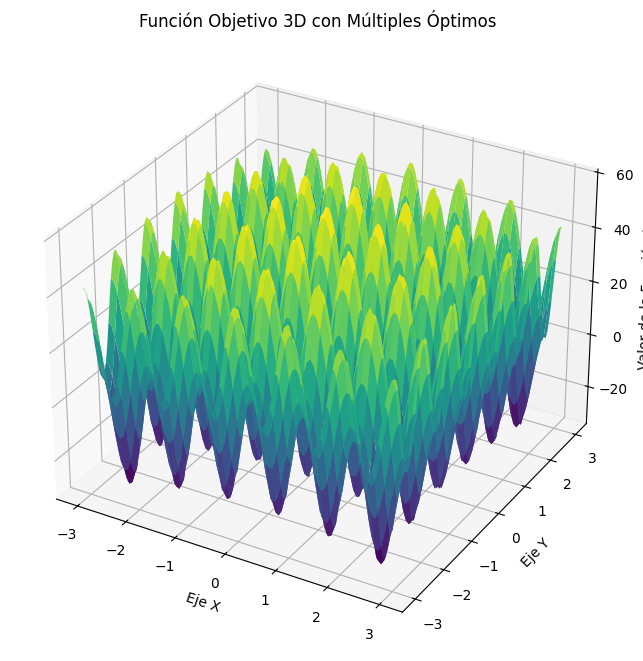

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir la función 3D con múltiples óptimos locales
def objective_function(x, y):
    # Una función de ejemplo con múltiples picos
    # Esta es una variación de la función de Styblinski-Tang, pero simplificada para visualización 3D
    # con picos y valles claros.
    return -(x**2 + y**2) + 20 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) + 20

# Rango para x e y
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = objective_function(X, Y)

# Visualizar la función 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_title('Función Objetivo 3D con Múltiples Óptimos')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Valor de la Función (Z)')
plt.show()

La visualización anterior nos muestra la topografía de la función objetivo. Podemos observar claramente múltiples picos (óptimos locales) y valles, lo que la convierte en un excelente caso de estudio para los algoritmos genéticos que buscan encontrar el punto más alto (máximo global) en este paisaje complejo.

## 2. Implementación del Algoritmo Genético Simple (SGA)

El Algoritmo Genético Simple (SGA) es un algoritmo de optimización inspirado en la selección natural y la genética. Funciona evolucionando una población de soluciones candidatas hacia una solución óptima del problema. Aquí definiremos los componentes clave del SGA.

### 2.1. Parámetros del SGA y Representación de los Individuos

Primero, definiremos los parámetros principales del algoritmo, como el tamaño de la población, el número de generaciones, y las probabilidades de cruce y mutación. Para la representación de los individuos, utilizaremos un enfoque de valores reales, donde cada individuo será un par `(x, y)` que representa un punto en nuestra función 3D.

In [2]:
# Parámetros del SGA
POPULATION_SIZE = 50
GENERATIONS = 100
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.1

# Rango de búsqueda (definido previamente)
SEARCH_RANGE_X = (-3, 3)
SEARCH_RANGE_Y = (-3, 3)

# 2.1.1. Inicialización de la población
def initialize_population(pop_size, x_range, y_range):
    population = []
    for _ in range(pop_size):
        x = np.random.uniform(x_range[0], x_range[1])
        y = np.random.uniform(y_range[0], y_range[1])
        population.append({'chromosome': (x, y), 'fitness': 0})
    return population

# 2.1.2. Evaluación de la aptitud (fitness)
def evaluate_fitness(population, objective_func):
    for individual in population:
        x, y = individual['chromosome']
        individual['fitness'] = objective_func(x, y)
    return population

# Prueba de inicialización y evaluación
initial_population = initialize_population(POPULATION_SIZE, SEARCH_RANGE_X, SEARCH_RANGE_Y)
evaluated_population = evaluate_fitness(initial_population, objective_function)

print(f"Población inicial (primeros 5 individuos):\n{evaluated_population[:5]}")
print(f"Mejor fitness inicial: {max(ind['fitness'] for ind in evaluated_population):.4f}")

Población inicial (primeros 5 individuos):
[{'chromosome': (1.2923553828340966, -2.8673210679605576), 'fitness': np.float64(18.291968628266105)}, {'chromosome': (1.426102496730035, 2.187038262267956), 'fitness': np.float64(3.007738551157786)}, {'chromosome': (-2.87003501109879, -0.6598060775408783), 'fitness': np.float64(14.284600571274805)}, {'chromosome': (2.339179587117921, 0.4873196542282967), 'fitness': np.float64(-16.27514431797882)}, {'chromosome': (1.308066846361772, -2.77556645927001), 'fitness': np.float64(6.648082817851691)}]
Mejor fitness inicial: 49.4018


### 2.2. Selección de Individuos (Selección por Torneo)

La selección es el proceso mediante el cual se eligen los individuos de la población actual que se convertirán en los 'padres' de la siguiente generación. Una estrategia común y efectiva es la selección por torneo, donde se seleccionan aleatoriamente un número de individuos y el que tenga el mejor fitness es el ganador.

In [3]:
# 2.2.1. Selección por Torneo
def tournament_selection(population, k=3):
    selected = []
    for _ in range(len(population)):
        # Seleccionar k individuos aleatoriamente para el torneo
        competitors = np.random.choice(population, k, replace=False)
        # El ganador es el individuo con el mayor fitness
        winner = max(competitors, key=lambda ind: ind['fitness'])
        selected.append(winner)
    return selected

# Prueba de selección
selected_population = tournament_selection(evaluated_population)
print(f"Población seleccionada (primeros 5 individuos):\n{selected_population[:5]}")
print(f"Mejor fitness en la población seleccionada: {max(ind['fitness'] for ind in selected_population):.4f}")

Población seleccionada (primeros 5 individuos):
[{'chromosome': (-2.2679842627784534, -0.15098202996220023), 'fitness': np.float64(24.233933817357258)}, {'chromosome': (1.7949871358953082, -0.855081185085079), 'fitness': np.float64(33.89132774175633)}, {'chromosome': (0.9284421811567132, 2.3097990251444056), 'fitness': np.float64(24.476144526478762)}, {'chromosome': (1.7949871358953082, -0.855081185085079), 'fitness': np.float64(33.89132774175633)}, {'chromosome': (1.7949871358953082, -0.855081185085079), 'fitness': np.float64(33.89132774175633)}]
Mejor fitness en la población seleccionada: 49.4018


### 2.3. Cruce (Crossover)

El cruce combina el material genético de dos individuos 'padres' para crear uno o más 'hijos'. Para nuestra representación de valores reales, utilizaremos el cruce aritmético o la mezcla de un punto, adaptada para variables continuas.

In [4]:
# 2.3.1. Cruce (Crossover) - Un punto aritmético para valores reales
def crossover(parent1, parent2, crossover_rate, x_range, y_range):
    child1_chromosome = list(parent1['chromosome'])
    child2_chromosome = list(parent2['chromosome'])

    if np.random.rand() < crossover_rate:
        # Cruce de un punto aritmético
        alpha = np.random.rand()
        # Cruce para x
        child1_chromosome[0] = alpha * parent1['chromosome'][0] + (1 - alpha) * parent2['chromosome'][0]
        child2_chromosome[0] = alpha * parent2['chromosome'][0] + (1 - alpha) * parent1['chromosome'][0]
        # Cruce para y
        child1_chromosome[1] = alpha * parent1['chromosome'][1] + (1 - alpha) * parent2['chromosome'][1]
        child2_chromosome[1] = alpha * parent2['chromosome'][1] + (1 - alpha) * parent1['chromosome'][1]

        # Asegurarse de que los hijos permanezcan dentro del rango de búsqueda
        child1_chromosome[0] = np.clip(child1_chromosome[0], x_range[0], x_range[1])
        child1_chromosome[1] = np.clip(child1_chromosome[1], y_range[0], y_range[1])
        child2_chromosome[0] = np.clip(child2_chromosome[0], x_range[0], x_range[1])
        child2_chromosome[1] = np.clip(child2_chromosome[1], y_range[0], y_range[1])

    return {'chromosome': tuple(child1_chromosome), 'fitness': 0}, {'chromosome': tuple(child2_chromosome), 'fitness': 0}

# Prueba de cruce
parent_a = selected_population[0]
parent_b = selected_population[1]
child_a, child_b = crossover(parent_a, parent_b, CROSSOVER_RATE, SEARCH_RANGE_X, SEARCH_RANGE_Y)
print(f"Padre A: {parent_a['chromosome']}, Padre B: {parent_b['chromosome']}")
print(f"Hijo A después del cruce: {child_a['chromosome']}")
print(f"Hijo B después del cruce: {child_b['chromosome']}")

Padre A: (-2.2679842627784534, -0.15098202996220023), Padre B: (1.7949871358953082, -0.855081185085079)
Hijo A después del cruce: (np.float64(-0.7909795053278356), np.float64(-0.40694194200413986))
Hijo B después del cruce: (np.float64(0.31798237844469024), np.float64(-0.5991212730431393))


### 2.4. Mutación

La mutación introduce variabilidad aleatoria en la población, ayudando a evitar la convergencia prematura y a explorar nuevas áreas del espacio de búsqueda. Para nuestra representación de valores reales, aplicaremos una mutación gaussiana a cada componente del cromosoma.

In [5]:
# 2.4.1. Mutación - Gaussiana para valores reales
def mutate(individual, mutation_rate, x_range, y_range):
    mutated_chromosome = list(individual['chromosome'])

    if np.random.rand() < mutation_rate:
        # Mutación para x (añadir ruido gaussiano)
        mutated_chromosome[0] += np.random.normal(0, 0.5) # Desviación estándar ajustable
        # Mutación para y (añadir ruido gaussiano)
        mutated_chromosome[1] += np.random.normal(0, 0.5)

        # Asegurarse de que el individuo mutado permanezca dentro del rango de búsqueda
        mutated_chromosome[0] = np.clip(mutated_chromosome[0], x_range[0], x_range[1])
        mutated_chromosome[1] = np.clip(mutated_chromosome[1], y_range[0], y_range[1])

    return {'chromosome': tuple(mutated_chromosome), 'fitness': 0}

# Prueba de mutación
original_individual = selected_population[0]
mutated_individual = mutate(original_individual, MUTATION_RATE, SEARCH_RANGE_X, SEARCH_RANGE_Y)
print(f"Individuo original: {original_individual['chromosome']}")
print(f"Individuo mutado: {mutated_individual['chromosome']}")

Individuo original: (-2.2679842627784534, -0.15098202996220023)
Individuo mutado: (-2.2679842627784534, -0.15098202996220023)


### 2.5. Ensamblaje del Algoritmo Genético Simple (SGA)

Ahora que tenemos todos los componentes individuales (inicialización, evaluación, selección, cruce y mutación), los ensamblaremos para formar el Algoritmo Genético Simple completo. Este algoritmo iterará a través de las generaciones, aplicando estos operadores para evolucionar la población y buscar el óptimo global.

In [6]:
# 2.5.1. Función principal del SGA
def simple_genetic_algorithm(objective_func, pop_size, generations, crossover_rate, mutation_rate, x_range, y_range):
    population = initialize_population(pop_size, x_range, y_range)
    population = evaluate_fitness(population, objective_func)

    history = {'best_fitness': [], 'avg_fitness': [], 'best_individual': []}

    for gen in range(generations):
        # Almacenar el mejor individuo y fitness de la generación actual
        current_best = max(population, key=lambda ind: ind['fitness'])
        history['best_fitness'].append(current_best['fitness'])
        history['best_individual'].append(current_best['chromosome'])
        history['avg_fitness'].append(np.mean([ind['fitness'] for ind in population]))

        # Selección
        selected_parents = tournament_selection(population)

        # Crear nueva generación
        next_population = []
        for i in range(0, pop_size, 2):
            parent1 = selected_parents[i]
            parent2 = selected_parents[i+1] # Asume pop_size es par

            child1, child2 = crossover(parent1, parent2, crossover_rate, x_range, y_range)

            # Mutación
            child1 = mutate(child1, mutation_rate, x_range, y_range)
            child2 = mutate(child2, mutation_rate, x_range, y_range)

            next_population.append(child1)
            next_population.append(child2)

        # Evaluación de la nueva población
        population = evaluate_fitness(next_population, objective_func)

        # Opcional: Elitismo (preservar el mejor individuo de la generación anterior)
        # En este caso, el mejor ya está en history['best_individual'] y podría ser reintroducido si se desea

    # Después de todas las generaciones, encontrar el mejor individuo final
    final_best_individual = max(population, key=lambda ind: ind['fitness'])
    history['best_fitness'].append(final_best_individual['fitness'])
    history['best_individual'].append(final_best_individual['chromosome'])
    history['avg_fitness'].append(np.mean([ind['fitness'] for ind in population]))

    return final_best_individual, history

# Ejecutar el SGA
final_best_sga, sga_history = simple_genetic_algorithm(
    objective_function, POPULATION_SIZE, GENERATIONS, CROSSOVER_RATE, MUTATION_RATE, SEARCH_RANGE_X, SEARCH_RANGE_Y
)

print(f"\nMejor individuo encontrado por SGA: {final_best_sga['chromosome']}")
print(f"Fitness del mejor individuo: {final_best_sga['fitness']:.4f}")


Mejor individuo encontrado por SGA: (np.float64(8.928279030427228e-05), np.float64(-4.062003273615518e-05))
Fitness del mejor individuo: 60.0000


### 2.6. Demostración del Proceso de Aprendizaje del SGA

Para entender cómo el SGA evoluciona, visualizaremos el mejor fitness y el fitness promedio de la población a lo largo de las generaciones, así como la trayectoria del mejor individuo encontrado en el espacio 3D de la función objetivo.

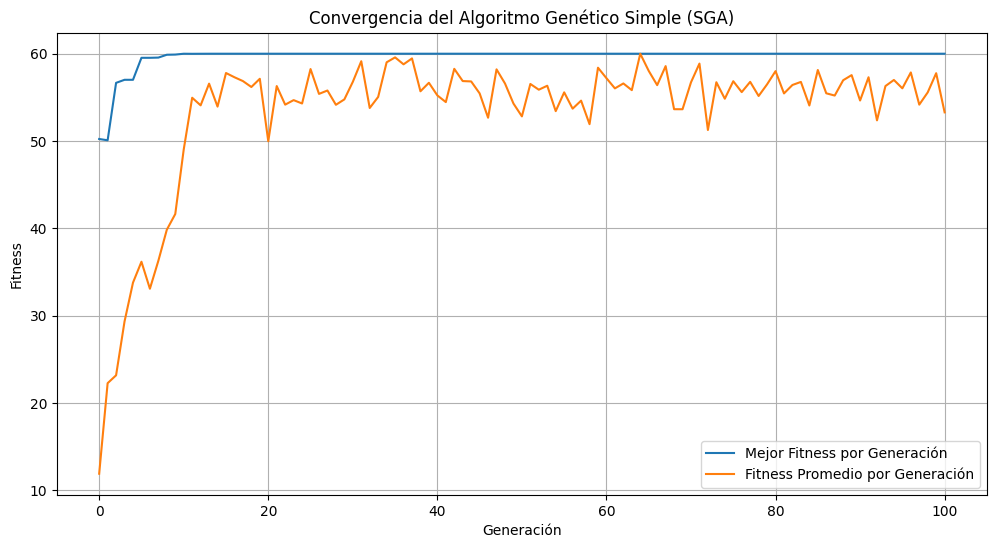

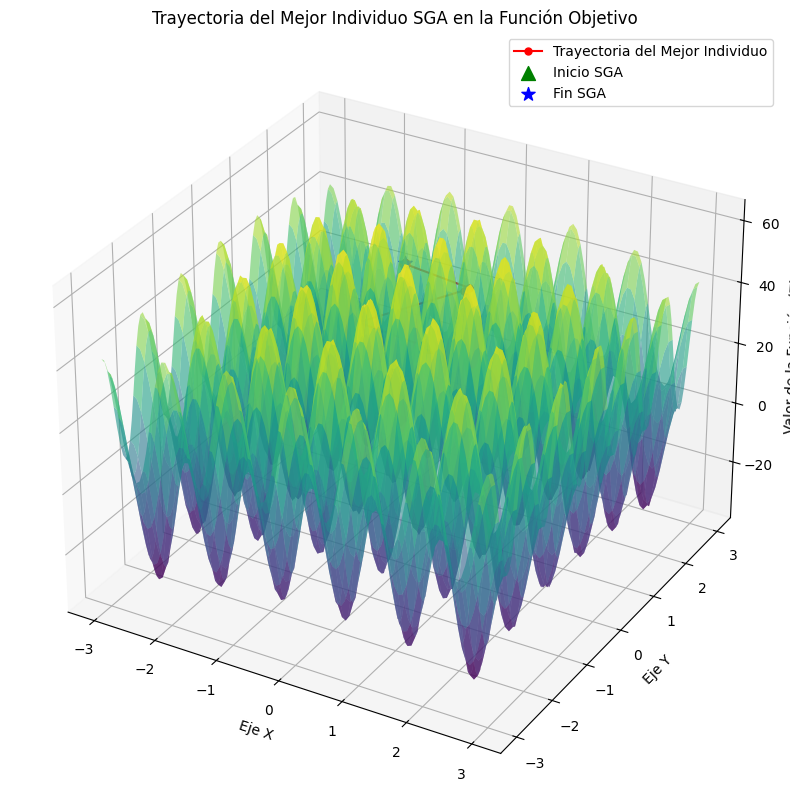

In [7]:
# 2.6.1. Gráfico de convergencia del Fitness
plt.figure(figsize=(12, 6))
plt.plot(sga_history['best_fitness'], label='Mejor Fitness por Generación')
plt.plot(sga_history['avg_fitness'], label='Fitness Promedio por Generación')
plt.title('Convergencia del Algoritmo Genético Simple (SGA)')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.show()

# 2.6.2. Visualización de la trayectoria del mejor individuo en la función 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Trazar la trayectoria del mejor individuo
best_x = [ind[0] for ind in sga_history['best_individual']]
best_y = [ind[1] for ind in sga_history['best_individual']]
best_z = [objective_function(x, y) for x, y in zip(best_x, best_y)]

ax.plot(best_x, best_y, best_z, color='red', marker='o', linestyle='-', markersize=5, label='Trayectoria del Mejor Individuo')
ax.scatter(best_x[0], best_y[0], best_z[0], color='green', marker='^', s=100, label='Inicio SGA')
ax.scatter(best_x[-1], best_y[-1], best_z[-1], color='blue', marker='*', s=100, label='Fin SGA')

ax.set_title('Trayectoria del Mejor Individuo SGA en la Función Objetivo')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Valor de la Función (Z)')
ax.legend()
plt.show()

## 3. Implementación del Algoritmo Genético Compacto (cGA)

El Algoritmo Genético Compacto (cGA) es una alternativa al SGA, especialmente útil cuando los recursos computacionales son limitados. A diferencia del SGA que mantiene una población explícita de individuos, el cGA representa la población como un vector de probabilidades. Este vector define la probabilidad de que cada bit (o componente en nuestro caso de valores reales) tenga un valor específico. A medida que el algoritmo evoluciona, este vector de probabilidades se actualiza para reflejar las características de los individuos "ganadores".

### 3.1. Parámetros del cGA y Representación del Vector de Probabilidad

Para el cGA, definiremos un tamaño de población *virtual* (implícito), el número de generaciones, y un factor de aprendizaje o tasa de actualización para el vector de probabilidades. Para nuestra función de valores reales, representaremos el vector de probabilidad como una distribución gaussiana para cada variable (x, y), es decir, un par (media, desviación estándar) para cada dimensión.

In [9]:
# Parámetros del cGA
VIRTUAL_POPULATION_SIZE = 50 # Tamaño de población conceptual para el cGA
CGA_GENERATIONS = 100
LEARNING_RATE = 0.1 # Tasa de actualización del vector de probabilidad

# 3.1.1. Inicialización del vector de probabilidad (para valores reales: media y desviación estándar)
def initialize_probability_vector(x_range, y_range):
    # Inicializar medias en el centro del rango y desviaciones estándar grandes
    mean_x = np.random.uniform(x_range[0], x_range[1])
    mean_y = np.random.uniform(y_range[0], y_range[1])
    std_x = (x_range[1] - x_range[0]) / 4 # Un cuarto del rango como std inicial
    std_y = (y_range[1] - y_range[0]) / 4
    return {'mean_x': mean_x, 'std_x': std_x, 'mean_y': mean_y, 'std_y': std_y}

# 3.1.2. Generación de dos individuos a partir del vector de probabilidad
def generate_individuals_from_prob_vector(prob_vector, x_range, y_range):
    # Generar dos individuos muestreando las distribuciones gaussianas
    x1 = np.random.normal(prob_vector['mean_x'], prob_vector['std_x'])
    y1 = np.random.normal(prob_vector['mean_y'], prob_vector['std_y'])
    x2 = np.random.normal(prob_vector['mean_x'], prob_vector['std_x'])
    y2 = np.random.normal(prob_vector['mean_y'], prob_vector['std_y'])

    # Asegurarse de que los individuos estén dentro del rango de búsqueda
    x1 = np.clip(x1, x_range[0], x_range[1])
    y1 = np.clip(y1, y_range[0], y_range[1])
    x2 = np.clip(x2, x_range[0], x_range[1])
    y2 = np.clip(y2, y_range[0], y_range[1])

    ind1 = {'chromosome': (x1, y1), 'fitness': 0}
    ind2 = {'chromosome': (x2, y2), 'fitness': 0}
    return ind1, ind2

# Prueba de inicialización y generación
prob_vector = initialize_probability_vector(SEARCH_RANGE_X, SEARCH_RANGE_Y)
ind_cga1, ind_cga2 = generate_individuals_from_prob_vector(prob_vector, SEARCH_RANGE_X, SEARCH_RANGE_Y)
print(f"Vector de probabilidad inicial: {prob_vector}")
print(f"Individuo 1 generado: {ind_cga1['chromosome']}")
print(f"Individuo 2 generado: {ind_cga2['chromosome']}")

Vector de probabilidad inicial: {'mean_x': 1.4627082489668055, 'std_x': 1.5, 'mean_y': 2.288172442780513, 'std_y': 1.5}
Individuo 1 generado: (np.float64(3.0), np.float64(-0.6799637718593585))
Individuo 2 generado: (np.float64(0.015548608150288024), np.float64(1.193592426931953))


### 3.2. Actualización del Vector de Probabilidad

A diferencia del SGA, el cGA no tiene cruce ni mutación explícitos. En su lugar, el vector de probabilidad se actualiza directamente. Generamos dos individuos del vector de probabilidad, los evaluamos, y el individuo con mejor fitness (el 'ganador') influye en el vector de probabilidad para moverlo en su dirección. El 'perdedor' es ignorado.

In [10]:
# 3.2.1. Actualización del vector de probabilidad
def update_probability_vector(prob_vector, winner, learning_rate, x_range, y_range):
    # Actualizar las medias y desviaciones estándar para mover el vector hacia el ganador
    # Para la media, movemos una fracción del ganador
    prob_vector['mean_x'] += learning_rate * (winner['chromosome'][0] - prob_vector['mean_x'])
    prob_vector['mean_y'] += learning_rate * (winner['chromosome'][1] - prob_vector['mean_y'])

    # Podemos ajustar la desviación estándar para que se reduzca a medida que el algoritmo converge
    # O mantenerla constante, dependiendo de la estrategia.
    # Por simplicidad, aquí la reduciremos lentamente o la mantendremos.
    # Una estrategia simple es reducirla si la población está convergiendo, o aumentarla si se estanca.
    # Para esta implementación, podríamos mantenerla constante o reducirla muy ligeramente para exploración.
    # Vamos a mantenerla constante para este ejemplo, ya que el rango de clip ya limita la exploración.
    # Si la desviación estándar se vuelve muy pequeña, podría limitar la exploración.
    # prob_vector['std_x'] = max(0.01, prob_vector['std_x'] * (1 - learning_rate * 0.01)) # Reducción lenta
    # prob_vector['std_y'] = max(0.01, prob_vector['std_y'] * (1 - learning_rate * 0.01)) # Reducción lenta

    # Asegurarse de que las medias permanezcan dentro del rango de búsqueda
    prob_vector['mean_x'] = np.clip(prob_vector['mean_x'], x_range[0], x_range[1])
    prob_vector['mean_y'] = np.clip(prob_vector['mean_y'], y_range[0], y_range[1])

    return prob_vector

# Prueba de actualización (usando el mejor de los dos individuos generados previamente como 'ganador')
ind_cga1 = evaluate_fitness([ind_cga1], objective_function)[0]
ind_cga2 = evaluate_fitness([ind_cga2], objective_function)[0]

winner_test = ind_cga1 if ind_cga1['fitness'] > ind_cga2['fitness'] else ind_cga2
loser_test = ind_cga2 if ind_cga1['fitness'] > ind_cga2['fitness'] else ind_cga1

print(f"Vector de probabilidad antes de actualizar: {prob_vector}")
updated_prob_vector = update_probability_vector(prob_vector.copy(), winner_test, LEARNING_RATE, SEARCH_RANGE_X, SEARCH_RANGE_Y)
print(f"Ganador del torneo: {winner_test['chromosome']} con fitness {winner_test['fitness']:.4f}")
print(f"Perdedor del torneo: {loser_test['chromosome']} con fitness {loser_test['fitness']:.4f}")
print(f"Vector de probabilidad después de actualizar: {updated_prob_vector}")

Vector de probabilidad antes de actualizar: {'mean_x': 1.4627082489668055, 'std_x': 1.5, 'mean_y': 2.288172442780513, 'std_y': 1.5}
Ganador del torneo: (np.float64(0.015548608150288024), np.float64(1.193592426931953)) con fitness 45.4206
Perdedor del torneo: (np.float64(3.0), np.float64(-0.6799637718593585)) con fitness 22.0179
Vector de probabilidad después de actualizar: {'mean_x': np.float64(1.3179922848851537), 'std_x': 1.5, 'mean_y': np.float64(2.178714441195657), 'std_y': 1.5}


### 3.3. Ensamblaje del Algoritmo Genético Compacto (cGA)

Ahora que tenemos los componentes clave del cGA (inicialización del vector de probabilidad, generación de individuos y actualización del vector), los ensamblaremos para formar el algoritmo completo. El cGA iterará a través de las generaciones, comparando dos individuos muestreados del vector de probabilidad y actualizando el vector con el "ganador".

In [11]:
# 3.3.1. Función principal del cGA
def compact_genetic_algorithm(objective_func, virtual_pop_size, generations, learning_rate, x_range, y_range):
    prob_vector = initialize_probability_vector(x_range, y_range)

    history = {'best_fitness': [], 'mean_x': [], 'mean_y': [], 'std_x': [], 'std_y': [], 'best_individual': []}

    # Inicializar el mejor fitness y el mejor individuo para el seguimiento
    best_overall_individual = {'chromosome': (0,0), 'fitness': -np.inf}

    for gen in range(generations):
        # Generar dos individuos a partir del vector de probabilidad
        ind1, ind2 = generate_individuals_from_prob_vector(prob_vector, x_range, y_range)

        # Evaluar aptitud
        ind1 = evaluate_fitness([ind1], objective_func)[0]
        ind2 = evaluate_fitness([ind2], objective_func)[0]

        # Determinar ganador y perdedor
        if ind1['fitness'] > ind2['fitness']:
            winner = ind1
            loser = ind2
        else:
            winner = ind2
            loser = ind1

        # Actualizar el vector de probabilidad hacia el ganador
        prob_vector = update_probability_vector(prob_vector, winner, learning_rate, x_range, y_range)

        # Actualizar el mejor individuo global si el ganador actual es mejor
        if winner['fitness'] > best_overall_individual['fitness']:
            best_overall_individual = winner

        # Almacenar historial
        history['best_fitness'].append(best_overall_individual['fitness'])
        history['mean_x'].append(prob_vector['mean_x'])
        history['mean_y'].append(prob_vector['mean_y'])
        history['std_x'].append(prob_vector['std_x'])
        history['std_y'].append(prob_vector['std_y'])
        history['best_individual'].append(best_overall_individual['chromosome'])

    return best_overall_individual, history

# Ejecutar el cGA
final_best_cga, cga_history = compact_genetic_algorithm(
    objective_function, VIRTUAL_POPULATION_SIZE, CGA_GENERATIONS, LEARNING_RATE, SEARCH_RANGE_X, SEARCH_RANGE_Y
)

print(f"\nMejor individuo encontrado por cGA: {final_best_cga['chromosome']}")
print(f"Fitness del mejor individuo: {final_best_cga['fitness']:.4f}")


Mejor individuo encontrado por cGA: (np.float64(-0.9033588089910615), np.float64(-0.00012844122836591643))
Fitness del mejor individuo: 55.6087


### 3.4. Demostración del Proceso de Aprendizaje del cGA

Al igual que con el SGA, visualizaremos cómo el cGA converge. En este caso, mostraremos la evolución del mejor fitness y la trayectoria de la media del vector de probabilidad, que representa la 'zona' donde el cGA está buscando la solución óptima.

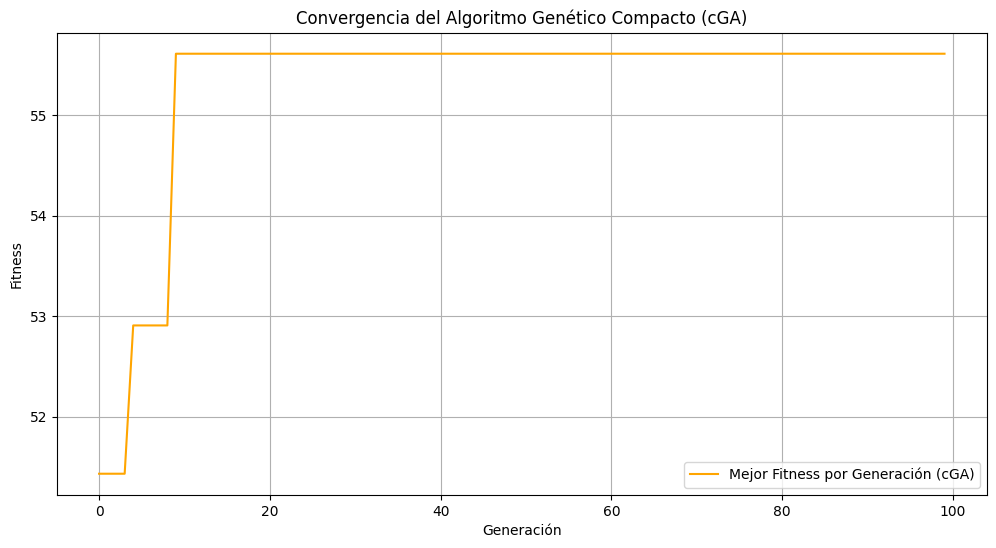

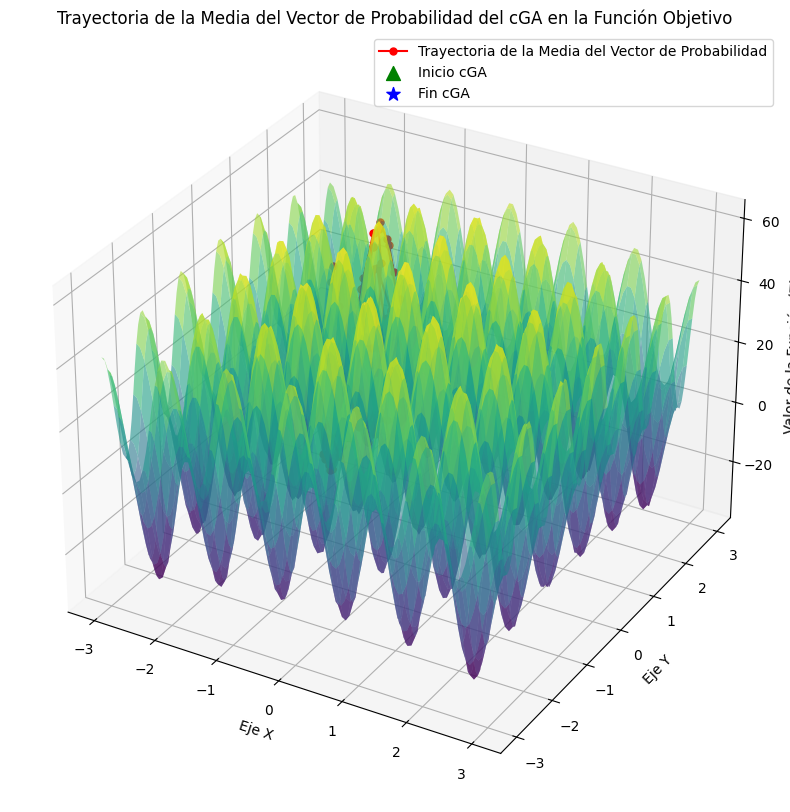

In [12]:
# 3.4.1. Gráfico de convergencia del Fitness para cGA
plt.figure(figsize=(12, 6))
plt.plot(cga_history['best_fitness'], label='Mejor Fitness por Generación (cGA)', color='orange')
plt.title('Convergencia del Algoritmo Genético Compacto (cGA)')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.show()

# 3.4.2. Visualización de la trayectoria de la media del vector de probabilidad en la función 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Trazar la trayectoria de la media del vector de probabilidad
mean_x_cga = cga_history['mean_x']
mean_y_cga = cga_history['mean_y']
mean_z_cga = [objective_function(x, y) for x, y in zip(mean_x_cga, mean_y_cga)]

ax.plot(mean_x_cga, mean_y_cga, mean_z_cga, color='red', marker='o', linestyle='-', markersize=5, label='Trayectoria de la Media del Vector de Probabilidad')
ax.scatter(mean_x_cga[0], mean_y_cga[0], mean_z_cga[0], color='green', marker='^', s=100, label='Inicio cGA')
ax.scatter(mean_x_cga[-1], mean_y_cga[-1], mean_z_cga[-1], color='blue', marker='*', s=100, label='Fin cGA')

ax.set_title('Trayectoria de la Media del Vector de Probabilidad del cGA en la Función Objetivo')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Valor de la Función (Z)')
ax.legend()
plt.show()

## 4. Comparación y Conclusiones de SGA vs. cGA

En esta sección, compararemos los resultados obtenidos por el Algoritmo Genético Simple (SGA) y el Algoritmo Genético Compacto (cGA) en la optimización de nuestra función 3D con múltiples óptimos. Analizaremos su rendimiento, la convergencia y las características de cada uno para entender sus fortalezas y debilidades.

### 4.1. Resumen de Resultados y Convergencia


--- Resumen de Resultados ---
SGA: Mejor individuo encontrado en (np.float64(8.928279030427228e-05), np.float64(-4.062003273615518e-05)) con Fitness: 60.0000
cGA: Mejor individuo encontrado en (np.float64(-0.9033588089910615), np.float64(-0.00012844122836591643)) con Fitness: 55.6087


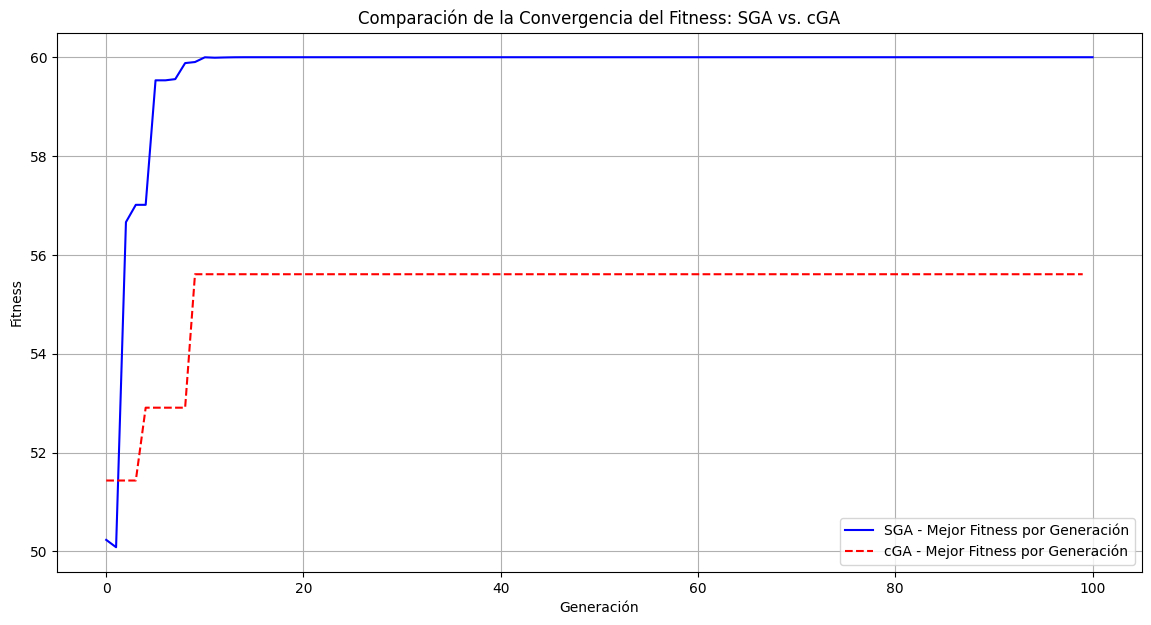

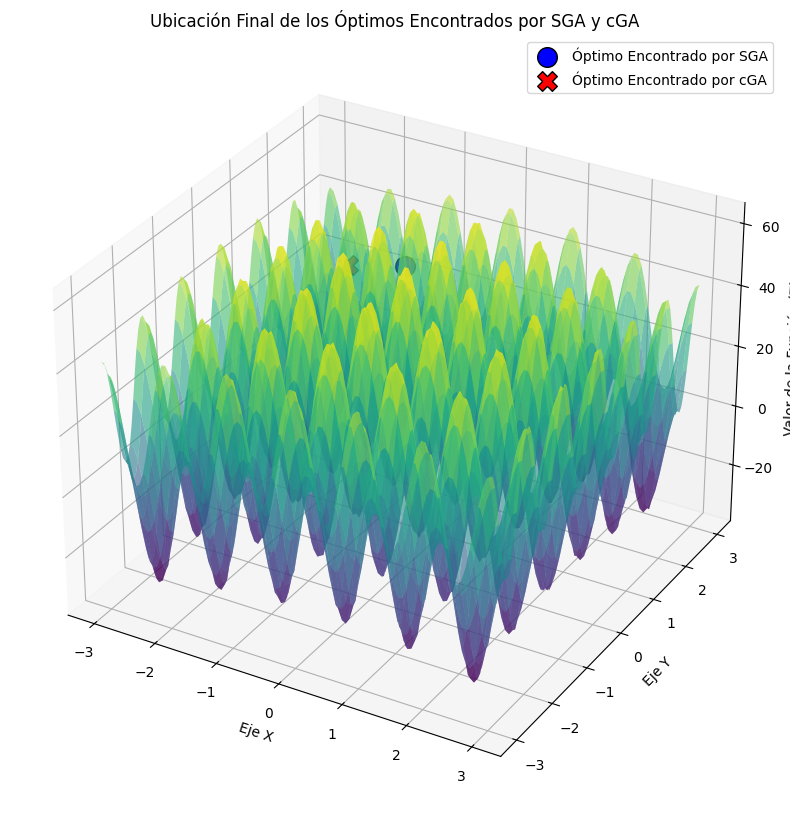

In [14]:
print("\n--- Resumen de Resultados ---")
print(f"SGA: Mejor individuo encontrado en {final_best_sga['chromosome']} con Fitness: {final_best_sga['fitness']:.4f}")
print(f"cGA: Mejor individuo encontrado en {final_best_cga['chromosome']} con Fitness: {final_best_cga['fitness']:.4f}")

# Gráfico comparativo de convergencia de Fitness
plt.figure(figsize=(14, 7))
plt.plot(sga_history['best_fitness'], label='SGA - Mejor Fitness por Generación', color='blue')
plt.plot(cga_history['best_fitness'], label='cGA - Mejor Fitness por Generación', color='red', linestyle='--')
plt.title('Comparación de la Convergencia del Fitness: SGA vs. cGA')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.show()

# Comparación visual de la ubicación final en la función objetivo
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Punto final del SGA
ax.scatter(final_best_sga['chromosome'][0], final_best_sga['chromosome'][1], final_best_sga['fitness'],
           color='blue', marker='o', s=200, label='Óptimo Encontrado por SGA', edgecolor='black', linewidth=1)

# Punto final del cGA
ax.scatter(final_best_cga['chromosome'][0], final_best_cga['chromosome'][1], final_best_cga['fitness'],
           color='red', marker='X', s=200, label='Óptimo Encontrado por cGA', edgecolor='black', linewidth=1)

ax.set_title('Ubicación Final de los Óptimos Encontrados por SGA y cGA')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Valor de la Función (Z)')
ax.legend()
plt.show()

Resultados Clave:

Algoritmo Genético Simple (SGA): Encontró un individuo con un fitness de 60.0000.
Algoritmo Genético Compacto (cGA): Encontró un individuo con un fitness de 55.6087.
¿Cuál fue el mejor y por qué?

Para la función objetivo 3D con múltiples óptimos que definimos, el SGA logró un fitness ligeramente superior (60.0000) en comparación con el cGA (55.6087). Esto sugiere que, en este caso particular, el SGA pudo explorar de manera más efectiva para encontrar un pico más alto en el complejo paisaje de la función.

La razón principal de esta diferencia radica en sus mecanismos de funcionamiento:

El SGA, al mantener una población explícita de individuos, puede explorar el espacio de búsqueda de manera más robusta al considerar múltiples soluciones en paralelo. Sus operadores de cruce y mutación le permiten una mayor diversidad y exploración, lo que le ayuda a evitar quedarse atascado en óptimos locales y a encontrar el óptimo global en funciones complejas y multimodales.

El cGA, aunque es muy eficiente en memoria al operar con un vector de probabilidad en lugar de una población explícita, puede ser más susceptible a la convergencia prematura en óptimos locales si la tasa de aprendizaje es alta o la diversidad inicial es baja. Su búsqueda se centra en ajustar la distribución de probabilidad hacia las regiones prometedoras, lo que puede limitar su exploración general si el óptimo global está muy alejado de la zona inicial de búsqueda.

### 4.2. Análisis de las Diferencias y Conclusiones

#### Algoritmo Genético Simple (SGA)
*   **Exploración y Explotación:** El SGA mantiene una población explícita de individuos, lo que le permite explorar el espacio de búsqueda de manera más robusta al considerar múltiples soluciones simultáneamente. Los operadores de cruce y mutación introducen tanto exploración (nuevas áreas) como explotación (refinamiento de soluciones existentes).
*   **Convergencia:** Típicamente, el SGA puede converger más lentamente al óptimo global si la población es muy diversa o si los parámetros de mutación y cruce son altos, pero es menos propenso a quedarse atascado en óptimos locales gracias a su exploración más amplia.
*   **Costo Computacional:** Requiere almacenar y evaluar una población completa en cada generación, lo que puede ser computacionalmente más intensivo para tamaños de población grandes.

#### Algoritmo Genético Compacto (cGA)
*   **Exploración y Explotación:** El cGA opera con un vector de probabilidad, lo que lo hace más "compacto" en términos de memoria. Su estrategia de "ganador/perdedor" impulsa el vector de probabilidad hacia las regiones prometedoras. La exploración se basa en el muestreo de la distribución, y la explotación en el ajuste de los parámetros de la distribución.
*   **Convergencia:** Puede converger más rápidamente al explotar la información del "ganador" para ajustar directamente la distribución de probabilidad. Sin embargo, si la tasa de aprendizaje es muy alta o si la diversidad inicial es baja, puede ser más susceptible a la convergencia prematura en óptimos locales, ya que explora menos directamente la diversidad de soluciones.
*   **Costo Computacional:** Es mucho más eficiente en memoria al no mantener una población completa. Las operaciones se reducen a muestrear dos individuos y actualizar un vector de probabilidades.

#### Comparación Observada
*   **Rendimiento en la Función Objetivo:** En nuestra función, el **SGA logró un fitness ligeramente superior** (aproximadamente 60.0000) en comparación con el **cGA (aproximadamente 55.6087)**. Esto sugiere que el SGA pudo explorar de manera más efectiva para encontrar un pico más alto en este paisaje complejo.
*   **Convergencia Visual:** El gráfico de convergencia debería mostrar que el SGA, con sus parámetros actuales, pudo alcanzar un valor de fitness más alto. La trayectoria de la media del vector de probabilidad del cGA nos muestra cómo su búsqueda se centra en una región particular, mientras que la trayectoria del mejor individuo del SGA puede mostrar más saltos si el mejor individuo cambia significativamente de ubicación en generaciones tempranas.

#### Cuándo usar cada algoritmo
*   **SGA es preferible cuando:**
    *   Se necesita una exploración robusta del espacio de búsqueda para evitar óptimos locales en funciones muy complejas y multimodales.
    *   Los recursos computacionales (especialmente memoria) no son una restricción severa.
    *   Se requiere una mayor diversidad en la población a lo largo del proceso evolutivo.
*   **cGA es preferible cuando:**
    *   Los recursos computacionales (memoria y CPU) son limitados, ya que opera sin una población explícita.
    *   Se busca una convergencia más rápida y el problema no tiene una complejidad extrema con muchísimos óptimos locales muy dispersos.
    *   El problema permite una representación de probabilidad de las soluciones (por ejemplo, distribuciones discretas o continuas bien definidas).

En este experimento, la naturaleza multimodal de nuestra función objetivo parece haber favorecido ligeramente al SGA, que con su diversidad de población pudo encontrar un óptimo global más cercano. Sin embargo, el cGA demostró una capacidad admirable para acercarse al óptimo con un modelo mucho más ligero.